# Classification with US Airline Sentiment Tweets

## Imports

In [1]:
'''General'''
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
'''Data'''
import pandas as pd
import numpy as np
"""Preprocessing"""
import re, string
import emoji
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import contractions
from collections import Counter
import spacy
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
'''Vectorization'''
from sklearn.feature_extraction.text import TfidfVectorizer
'''EDA'''
from nltk.probability import FreqDist
'''Baseline Classification'''
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
'''Visualization'''
import seaborn as sns
import matplotlib.pyplot as plt
'''Local'''
from src.eda import *
from src.preprocessing import *
from src.ann_classification import *
from src.ann_utility import *

# sns.set_palette("deep")
sns.set_theme(context='paper',
              style='white',
              font_scale=1.5,
              palette='viridis')

pd.set_option('display.max_columns', 200)

# Source Code

In [ ]:
#============================================================================
# Preprocessing
#============================================================================
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


STOP_WORDS = set(stopwords.words('english'))
# I noticed that the lemmatizer
# converted the 'us' to 'u'
# so I did an update
STOP_WORDS.update({"u", "us", "dm", "fleet", "fleek"})

NORMALIZE_MAP = {}

SLANG_MAP = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "b": "be",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
}

## Data Preprocessing & EDA

In [3]:
filepath = "../data/01_raw/Tweets.csv"

tweets_df = pd.read_csv(filepath)
tweets_df.head(20)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


In [4]:
#------------------------------------------------------------
# DataFrame exploration
#------------------------------------------------------------
print("\n-------- DF Columns --------")
print(tweets_df.columns)

tweets_df = tweets_df[['airline_sentiment', 'text']].copy()

tweets_df.head(10)
print("\n-------- Info --------")
print(tweets_df.info())
print("\n-------- Missing Values --------")
print(tweets_df.isna().sum())
print(tweets_df['text'].sample(10))

print("\n-------- Random Sample Tweets --------")
print("Text 1:", tweets_df['text'].iloc[18])
print("Text 2:", tweets_df['text'].iloc[100])
print("Text 3:", tweets_df['text'].iloc[200])


-------- DF Columns --------
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

-------- Info --------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   airline_sentiment  14640 non-null  object
 1   text               14640 non-null  object
dtypes: object(2)
memory usage: 228.9+ KB
None

-------- Missing Values --------
airline_sentiment    0
text                 0
dtype: int64
9424     @USAirways can I speak to a human with some co...
13412    @AmericanAir thanks to Jacqueline in CLT for c...
6414     @SouthwestAir  you are over 40, please start a...
407

In [5]:
#------------------------------------------------------------
# Preprocessing
#------------------------------------------------------------
tweets_df['text'] = tweets_df['text'].apply(preprocess)
print(tweets_df['text'].iloc[18])
tweets_df['tokens'] = tweets_df['text'].apply(tokenize_and_clean)
print(tweets_df['tokens'].sample(5))
tweets_df['tokens'] = tweets_df['tokens'].apply(pos_tag_and_lemmatize)
print(tweets_df['tokens'].iloc[10])

i redheart flying smilingfacethumbsup
5595                  [asshole, cut, front, system, blows]
2726     [sad, think, important, resolve, client, facin...
14472    [run, engine, troubleshoot, issue, boarding, p...
6918            [people, working, contact, project, works]
12327    [thanks, recommendation, sitting, minutes, las...
Name: tokens, dtype: object
['know', 'suicide', 'second', 'lead', 'death', 'among', 'teen']


### EDA

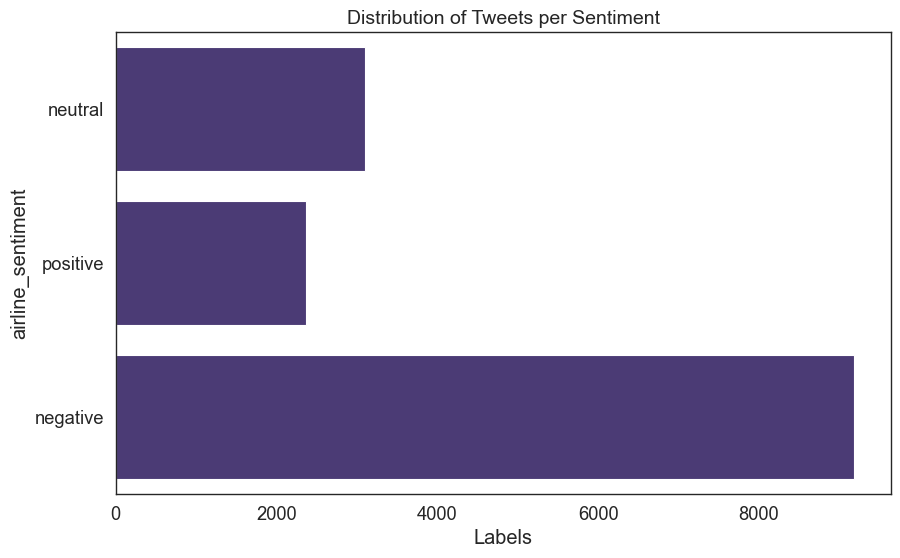

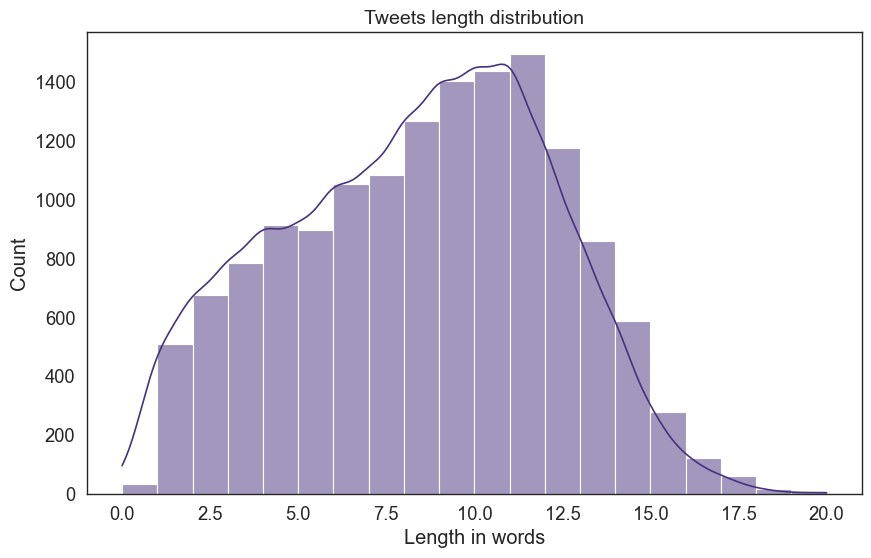

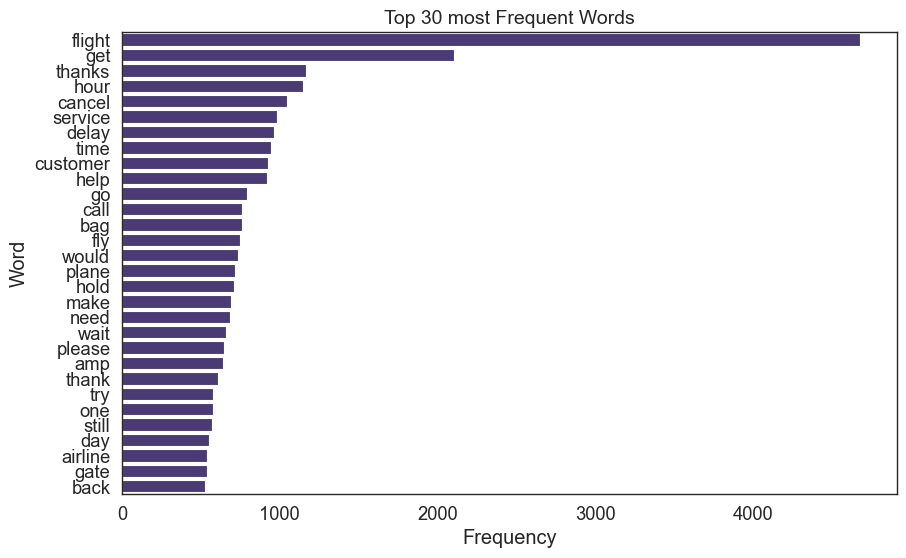

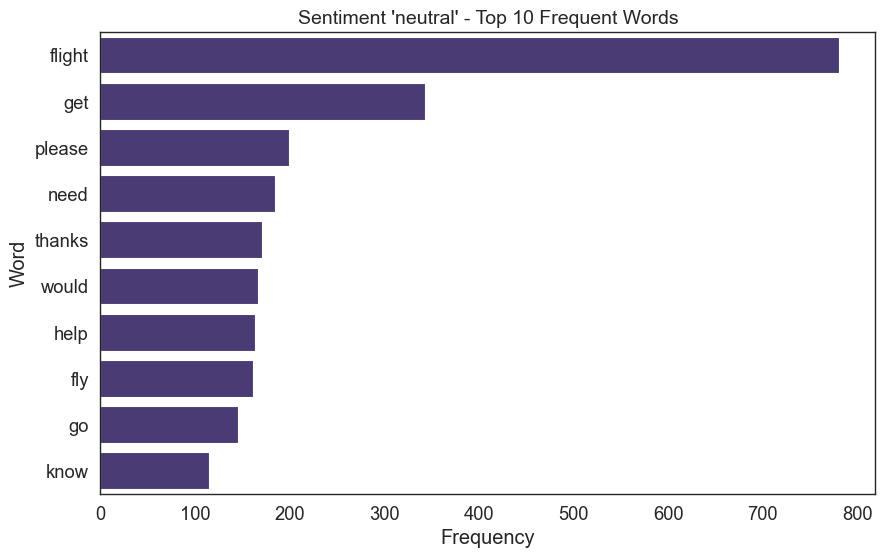

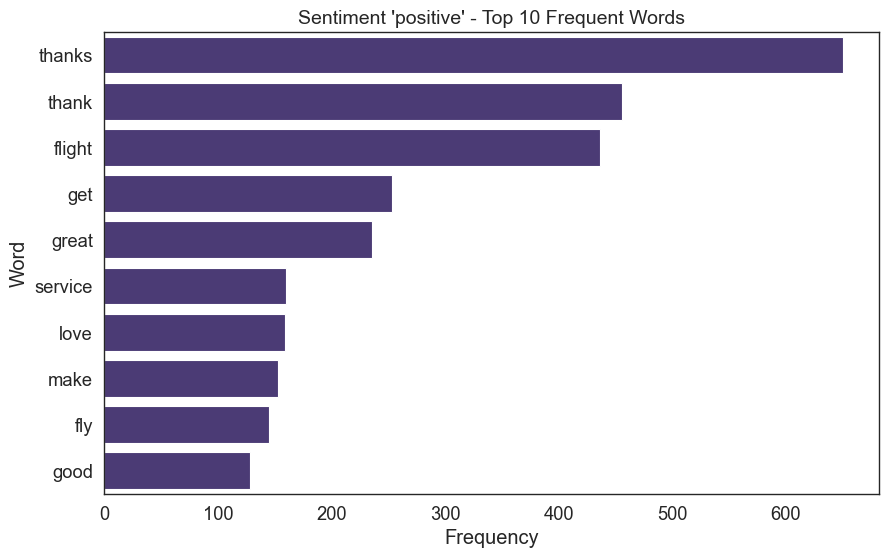

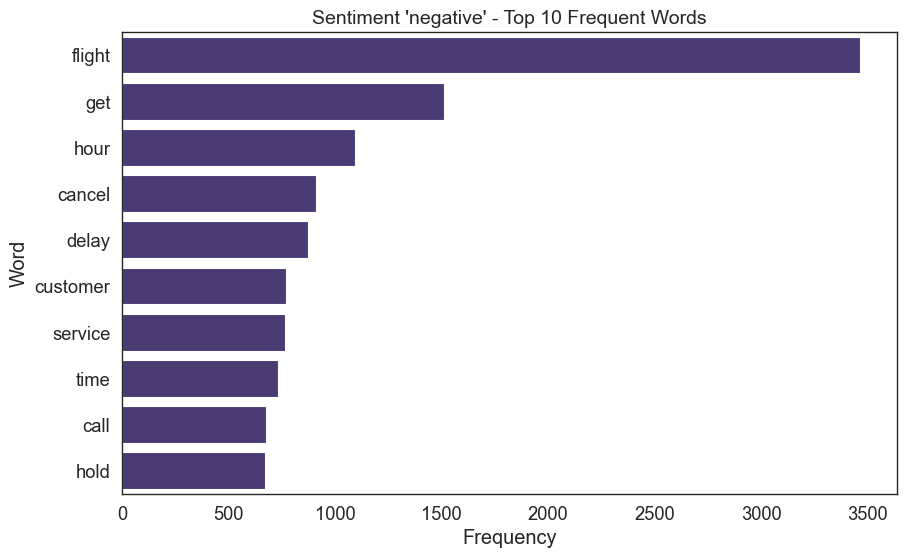

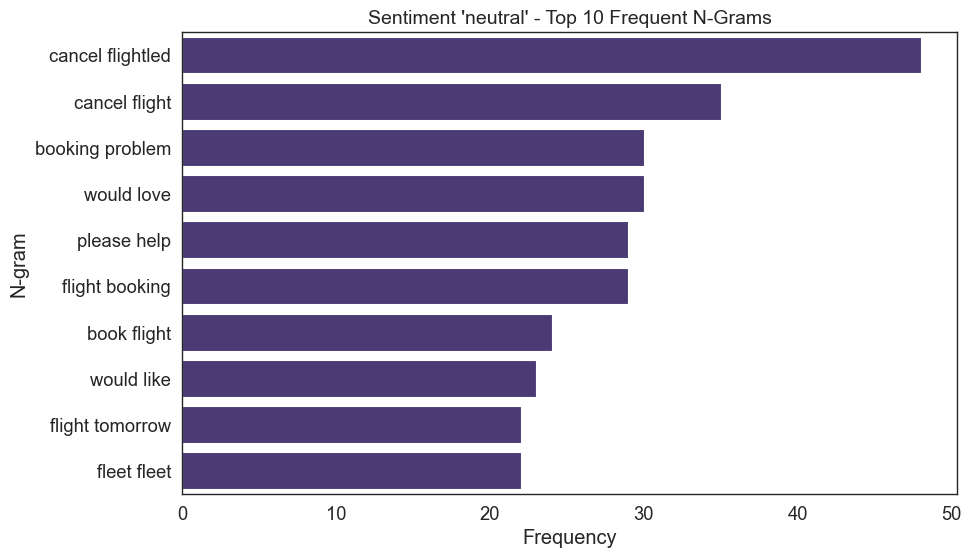

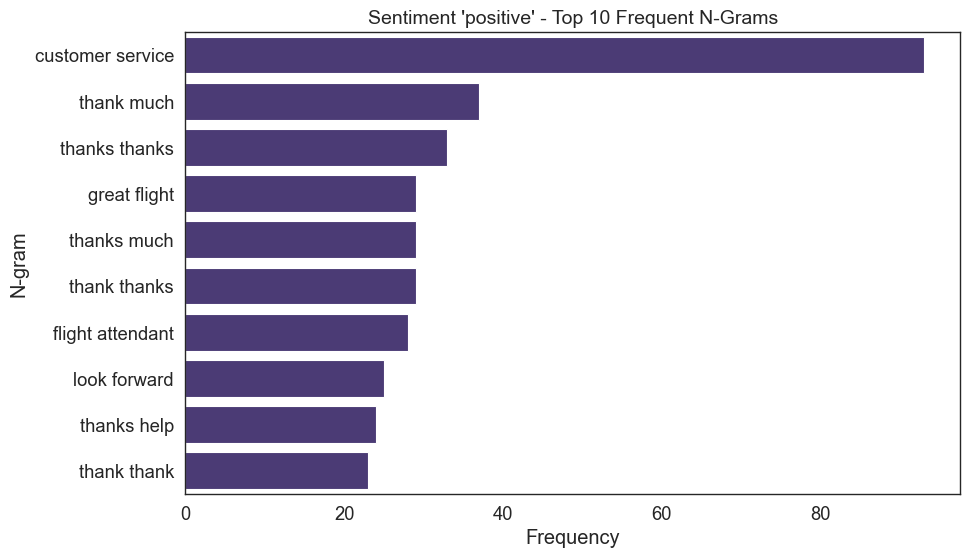

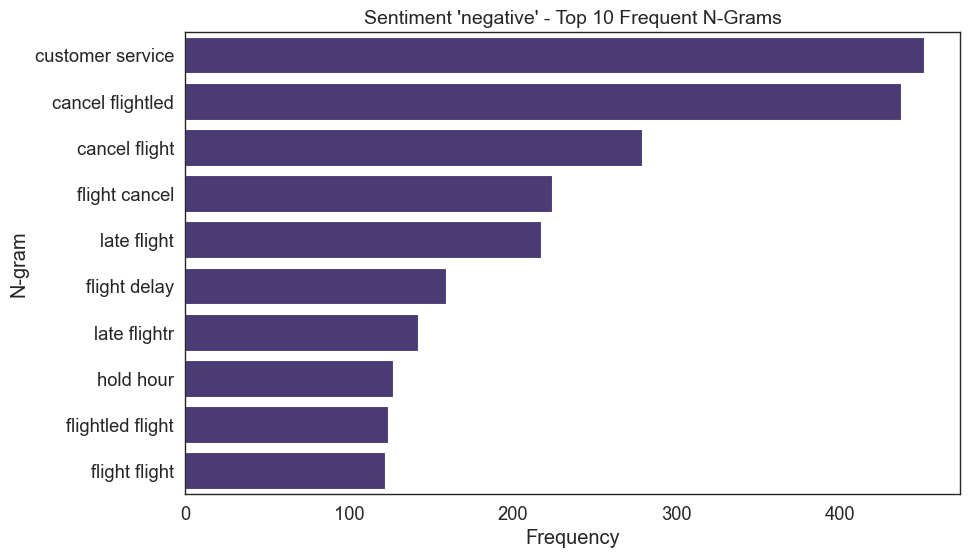

In [ ]:
#------------------------------------------------------------
# Target Analysis
#------------------------------------------------------------
# Sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=tweets_df, y='airline_sentiment')
plt.title("Distribution of Tweets per Sentiment", fontsize=14)
plt.xlabel("Number of Tweets")
plt.xlabel("Labels")
plt.show()

tweets_length = pd.DataFrame()
tweets_length['Length'] = tweets_df['tokens'].apply(len)

# Plot Tweet Length distribution
plt.figure(figsize=(10, 6))
sns.histplot(tweets_length, x='Length', bins=20, kde=True)
plt.title("Tweets length distribution", fontsize=14)
plt.xlabel("Length in words")
plt.show()

#------------------------------------------------------------
# Sentiment Analysis
#------------------------------------------------------------
# Most Common Words
num_words = 30
all_tokens = [token for tokens in tweets_df['tokens'] for token in tokens]
fdist = FreqDist(all_tokens)
top_words = fdist.most_common(num_words)

df_top = pd.DataFrame(top_words, columns=['word', 'count'])

plot_horizontal_bar(df_top,
                    x='count',
                    y='word',
                    title=f'Top {num_words} most Frequent Words',
                    xlabel='Frequency',
                    ylabel='Word'
                    )


top_ten_dict = {}
n_top_words = 10
top_ngrams_dict = {}


# Most common words per sentiment
top_words_dict  = get_top_by_sentiment(tweets_df, 'airline_sentiment', 'tokens')
# Most common n-grams per sentiment
top_ngrams_dict = get_top_by_sentiment(tweets_df, 'airline_sentiment', 'tokens', ngram=2)

# Plot most common words per sentiment
for sentiment, top_df in top_words_dict.items():
    plot_horizontal_bar(top_df,
                        x='count',
                        y='word',
                        title=f"Sentiment '{sentiment}' - Top {n_top_words} Frequent Words",
                        xlabel='Frequency',
                        ylabel='Word'
                        )


# Plot most common ngrams per sentiment
for sentiment, top_df in top_ngrams_dict.items():
    top_df['n_gram'] = top_df['word'].apply(lambda x: " ".join(x))
    plot_horizontal_bar(top_df,
                        x='count',
                        y='n_gram',
                        title=f"Sentiment '{sentiment}' - Top {n_top_words} Frequent N-Grams",
                        xlabel='Frequency',
                        ylabel='N-gram'
                        )

**Labels**

The above analysis shows that the labels distribution is very unbalanced. The negative
Tweets seem to outweigh the positive and neutral comment.


**Sentiment**

In the 'top word' plots we can observe the following:
- 'flight' is the most frequent word overall and among the top for each sentiment
- 'thank' and 'thanks' was not preprocessed well with the POS and Lemmatization pipeline
- Wrong words, like 'flighled', 'flightr', 'flighted'. Probably they are residuals from the hastag preprocessing.
- Consecutive duplicates

I will further patch the preprocessing by 
- further remove duplicates 
- patch 'flightled, flightr, flighted' to 'flight


The 'flight' is the most common word among all three sentiments. For any other case of vectorization, except 'TF-IDF', the word 'flight' had to be deleted.
However, as TF-IDF penalizes common words across documents and is the main vectorizer for this analysis, I will not remove the 'flight' word. 

In [ ]:
#============================================================
# Preprocessing patch
#============================================================
NORMALIZE_MAP = {
    "thanks": "thank",
    "flightled": "flight",
    "flightr": "flight",
    "flighted": "flight",
}

tweets_df['tokens'] = tweets_df['tokens'].apply(normalize_tokens)
tweets_df['tokens'] = tweets_df['tokens'].apply(remove_consecutive_dupes)

# Sanity check after the patch
top_words_dict  = get_top_by_sentiment(tweets_df, 'airline_sentiment', 'tokens')
top_ngrams_dict = get_top_by_sentiment(tweets_df, 'airline_sentiment', 'tokens', ngram=2)

print("\nTop words per sentiment")
print(top_words_dict)
print("\nTop ngrams per sentimetn")
print(top_ngrams_dict)


Top words per sentiment
{'neutral':      word  count
0  flight    773
1     get    339
2  please    193
3    need    184
4  thanks    171
5   would    166
6    help    163
7     fly    160
8      go    144
9    know    115, 'positive':       word  count
0   thanks    648
1    thank    447
2   flight    429
3      get    253
4    great    236
5  service    160
6     love    157
7     make    152
8      fly    145
9     good    128, 'negative':        word  count
0    flight   3357
1       get   1506
2      hour   1090
3    cancel    913
4     delay    869
5  customer    770
6   service    762
7      time    732
8      hold    673
9      call    672}

Top ngrams per sentimetn
{'neutral':                   word  count
0  (cancel, flightled)     48
1     (cancel, flight)     35
2   (booking, problem)     30
3        (would, love)     30
4       (please, help)     29
5    (flight, booking)     29
6       (book, flight)     24
7        (would, like)     23
8   (flight, tomorrow)     22
9   

### Train Test Split

In [8]:
# Label Encoding
le_ann = LabelEncoder()
tweets_df['label'] = le_ann.fit_transform(tweets_df['airline_sentiment'])


#Rejoin tokenized words
tweets_df['text_clean'] = tweets_df['tokens'].apply(lambda t: " ".join(t))

# Split Train, Test
X_train, X_test, y_train, y_test = train_test_split(
    tweets_df['text_clean'], tweets_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=tweets_df['label']
)

# Split Train, Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size = 0.125, random_state=42
)


### Vectorization

For the vectorization of the text I will use the TF-IDF method. The decision is based on the following reasons:

1. With an average tweet length of ~10 words, each word occurrence is significant. Word2Vec/FastText require averaging word vectors per tweet, which may not catch the importance over this small number of tokens.
2. TF-IDF will penalizes frequent words like "flight" (which appears across all sentiment classes) 
3. Bigram support: With ngram_range=(1,2), TF-IDF captures meaningful phrases 
4. Simplicity and no extra training or dependencies.

In [9]:
n_vec_features = 6000
tfidf_vectorizer = TfidfVectorizer(max_features=n_vec_features, ngram_range=(1,2))

# Fit transform and convert to np.ndarray
X_train_vec = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_vec = tfidf_vectorizer.transform(X_test).toarray()
X_val_vec = tfidf_vectorizer.transform(X_val).toarray()

# Convert to np.ndarray
y_train_vec = np.array(y_train, dtype=np.float32)
y_test_vec = np.array(y_test, dtype=np.float32)
y_val_vec = np.array(y_val, dtype=np.float32)

In [11]:
print("\n------ X sample shapes: ------")
print("\nX train shape: ", X_train_vec.shape)
print("X test shape:  ", X_test_vec.shape)
print("X val shape:   ", X_val_vec.shape)


print("\n------ Y sample shapes: ------")
print("\ny train shape: ", y_train.shape)
print("y test shape:  ", y_test.shape)
print("y val shape:   ", y_val.shape)


------ X sample shapes: ------

X train shape:  (10248, 6000)
X test shape:   (2928, 6000)
X val shape:    (1464, 6000)

------ Y sample shapes: ------

y train shape:  (10248,)
y test shape:   (2928,)
y val shape:    (1464,)


## Logistic Regression - Baseline

In [12]:
# Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)

# Predict on test
lr_preds = lr_model.predict(X_test_vec)

# Evaluate
print(classification_report(y_test, lr_preds,labels=[0,1,2], target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.79      0.94      0.86      1835
     Neutral       0.66      0.45      0.54       620
    Positive       0.79      0.56      0.66       473

    accuracy                           0.77      2928
   macro avg       0.75      0.65      0.68      2928
weighted avg       0.76      0.77      0.76      2928



## Analysis with ANN

Epoch [1/200], 
 Train Loss:   1.090288 | Train Acc:    0.472482
 Test Loss:    1.078939 |  Test Acc:     0.636612
Model improved.!
Epoch [2/200], 
 Train Loss:   1.063126 | Train Acc:    0.625683
 Test Loss:    1.039144 |  Test Acc:     0.636612
Model improved.!
Epoch [3/200], 
 Train Loss:   1.010498 | Train Acc:    0.625585
 Test Loss:    0.966896 |  Test Acc:     0.636612
Model improved.!
Epoch [4/200], 
 Train Loss:   0.927414 | Train Acc:    0.625585
 Test Loss:    0.875461 |  Test Acc:     0.636612
Model improved.!
Epoch [5/200], 
 Train Loss:   0.848294 | Train Acc:    0.625585
 Test Loss:    0.816762 |  Test Acc:     0.636612
Model improved.!
Epoch [6/200], 
 Train Loss:   0.802437 | Train Acc:    0.625585
 Test Loss:    0.785020 |  Test Acc:     0.636612
Model improved.!
Epoch [7/200], 
 Train Loss:   0.764091 | Train Acc:    0.626561
 Test Loss:    0.754052 |  Test Acc:     0.647541
Model improved.!
Epoch [8/200], 
 Train Loss:   0.724657 | Train Acc:    0.642272
 Test Loss:

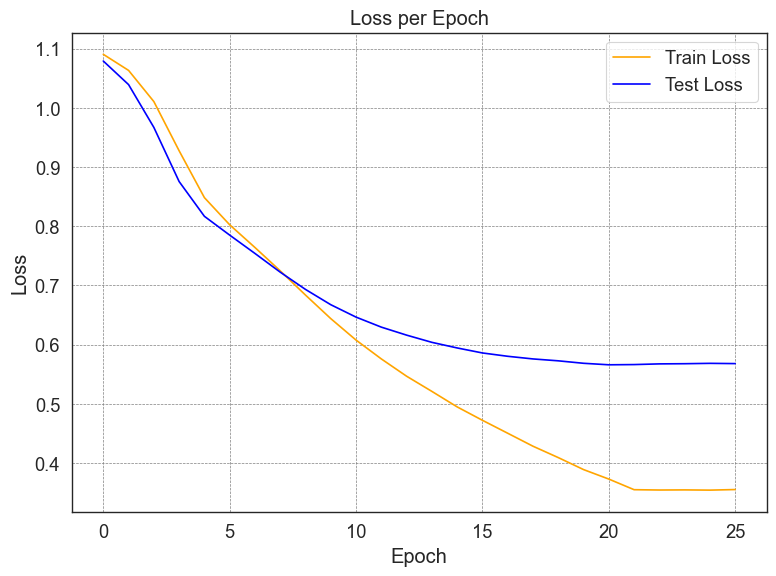

Model Parameters:
network.0.weight                         -> (256, 6000)
network.0.bias                           -> (256,)
network.3.weight                         -> (128, 256)
network.3.bias                           -> (128,)
network.6.weight                         -> (3, 128)
network.6.bias                           -> (3,)

Total number of learnable parameters: 1569539


-------------Validation Set-------------

Acuuracy Score:    0.7766

Precision Score: 0.7312

Recall Score:    0.6658

F1 Score:        0.6917

Confusion Matrix:

[[854  65  13]
 [132 147  26]
 [ 57  34 136]]


----------------Test Set----------------

Acuuracy Score:    0.7783

Precision Score: 0.7352

Recall Score:    0.6765

F1 Score:        0.7000

Confusion Matrix:

[[1671  131   33]
 [ 240  332   48]
 [ 113   84  276]]


In [13]:
# =============================================================================
# Create Datasets & DataLoaders
# =============================================================================

device = 'cpu'

torch.manual_seed(42)

batch_size = 128

train_dataset = EmbeddingsDataset(X_train_vec, y_train_vec, device=device)
test_dataset = EmbeddingsDataset(X_test_vec, y_test_vec, device=device)
val_dataset = EmbeddingsDataset(X_val_vec, y_val_vec, device=device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# =============================================================================
# Model definition
# =============================================================================

# Dimensionality of the input features
input_dim = X_train_vec.shape[1]

# Number of neurons per hidden layer
hidden_layers = [256, 128]

model = MLP(input_dim, hidden_layers, dropout_prob=0.2).to(device)


# =============================================================================
# Loss and Optimizer Definition
# =============================================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# =============================================================================
# Model Training and Testing
# =============================================================================

# Number of training epochs
epochs = 200

# Actual training
model, train_loss, train_acc, test_loss, test_acc, train_test_predictions = train_model(model,
                                                                                        train_loader,
                                                                                        val_loader,
                                                                                        criterion,
                                                                                        optimizer,
                                                                                        epochs,
                                                                                        patience=5 )
# Plot the training history
plot_training_history(train_loss, test_loss)

# Get predictions for the training set
test_preds, test_actuals = get_predictions(model, test_loader)

# Get prediction for the test set
val_preds, val_actuals = get_predictions(model, val_loader)

# Network Parameters
report_model_parameters(model)

# Validation metrics of
report_validation_metrics(val_actuals, val_preds, labels=[0, 1, 2] , case='Validation Set')
report_validation_metrics(test_actuals, test_preds, labels=[0, 1, 2] , case='Test Set')




## Results Interpretation

**ANN Hyperparameters**

After some tunning, both in the feature size of the vectorizer and the hidden layer number and size and batch size the configuration of a two layer neural network with [256, 128] and a batch size of 128 seem to be giving the best results. An increase in the hidden layers leeds to overfitting and worst F1 scores. 

**Overall**

The ANN outperforms the baseline mainly in recall (+0.03). More specifically, the ANN seems to be better at finding samples from the Negative and Neutral classes
- At Neutral: 
  - LR catches 45% of Neutral tweets, 
  - the ANN catches roughly 54% (332/620).


Both models seems to be week at classifying the Neutral class. The confusion matrix shows **240 Neutral tweets misclassified as Negative**. This makes sense, as in the top word and ngram analysis
the words and ngrams did were not very distinctive, as in the Negative and Positive classes.


Overall the ANN's non-linear hidden layers gives a boost, improving the macro F1 from 0.68 to 0.70. The improvement is modest but consistent across both val and test sets, confirming it's genuine and not overfitting.